In [1]:
import sys
print(sys.executable)


C:\Users\USUARIO\AppData\Local\pypoetry\Cache\virtualenvs\desarrollo-social-y-economico-SY8rErmS-py3.12\Scripts\python.exe


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_parquet(
    "datos/cruce_secop_dane_sprint2.parquet"
)

df.head()

,código_departamento,nombre_departamento,código_municipio,nombre_municipio,necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%),necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_miseria,necesidades_basicas_insatisfechas_por_categorias_%_componente_vivienda,necesidades_basicas_insatisfechas_por_categorias_%_componente_servicios,necesidades_basicas_insatisfechas_por_categorias_%_componente_hacinamiento,necesidades_basicas_insatisfechas_por_categorias_%_componente_inasistencia,...,etnia_afro_count,etnia_ninguno_count,etnia_sin_info_count,etnia_indigena_pct,etnia_rrom_pct,etnia_raizal_pct,etnia_palenquero_pct,etnia_afro_pct,etnia_ninguno_pct,etnia_sin_info_pct
0,05,ANTIOQUIA,001,MEDELLÍN,5.230398664972173,0.41728094869016497,0.28464264571461745,0.1887023524441256,1.555427767002387,1.6148819328409472,...,59064.0,2279605.0,31165.0,0.087298,0.002023,0.013236,0.002656,2.489704,96.091395,1.313687
1,05,ANTIOQUIA,002,ABEJORRAL,13.958914243441644,1.3657315199453708,0.37557616798497695,0.4950776759801969,2.663176463893473,1.2405394639503784,...,62.0,17428.0,107.0,0.011364,0.000000,0.000000,0.000000,0.352293,99.028354,0.607989
2,05,ANTIOQUIA,004,ABRIAQUÍ,11.630079402148528,1.2143858010275572,1.7281644091546007,1.5880429705744978,2.335357309668379,0.6071929005137786,...,43.0,2091.0,24.0,0.000000,0.046318,0.000000,0.000000,1.991663,96.850394,1.111626
3,05,ANTIOQUIA,021,ALEJANDRÍA,12.676424464192367,0.8886565603763722,0.705697856769472,0.07841087297438579,1.9864087820177732,0.8886565603763722,...,12.0,3797.0,30.0,0.000000,0.000000,0.000000,0.000000,0.312581,98.905965,0.781454
4,05,ANTIOQUIA,030,AMAGÁ,9.663881290515981,0.9367857009030615,0.5283471353093266,0.2772885674673062,2.3681942518829393,1.907295687038633,...,125.0,26608.0,74.0,0.033556,0.007457,0.000000,0.011185,0.466053,99.205846,0.275903


Detección de Clusters de Alta/Baja Inversión Pública — Mapa de Significancia (LISA)

Usamos el índice de Moran Local (LISA) sobre el monto per cápita de inversión. Los municipios se clasifican en cuatro categorías: **High-High** (clúster de alta inversión), **Low-Low** (clúster de baja inversión), **High-Low** y **Low-High** (outliers espaciales). Solo se muestran los municipios estadísticamente significativos (p < 0.05).

 **Detección de Clusters Espaciales (LISA)**

✅ libpysal y esda cargados correctamente
ANÁLISIS DE CLUSTERS ESPACIALES — LISA (Moran Local)
ℹ️  No se encontraron coordenadas reales. Se usa proxy DIVIPOLA.
   Filas descartadas por DIVIPOLA inválido: 0
   Municipios en análisis espacial: 1124

📊 Distribución de clusters:
High-High: 2
High-Low: 6
Low-High: 35
Low-Low: 1081

🌐 Moran Global I = 0.0338 | p = 0.0900


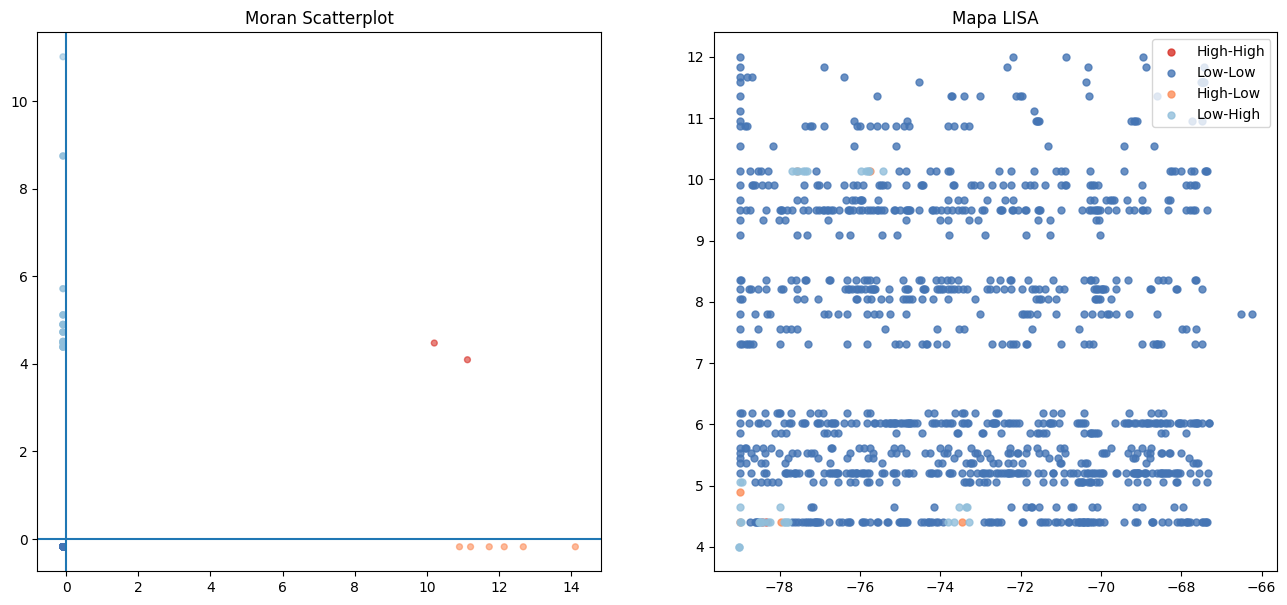

In [3]:
# ============================================================================
# 16. DETECCIÓN DE CLUSTERS ESPACIALES (LISA) — MAPA DE SIGNIFICANCIA
# ============================================================================

# 🔥 Instalar correctamente en el entorno del notebook
import sys
!{sys.executable} -m pip install libpysal esda

# Importar librerías espaciales
from libpysal.weights import KNN
from esda.moran import Moran_Local, Moran
SPATIAL_AVAIL = True
print("✅ libpysal y esda cargados correctamente")

# Librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("=" * 65)
print("ANÁLISIS DE CLUSTERS ESPACIALES — LISA (Moran Local)")
print("=" * 65)

# ── 1. Variable de análisis ───────────────────────────────────────────────
df_lisa = df.copy()
df_lisa['log_monto'] = np.log1p(df_lisa['monto_total_contratos'].fillna(0))

# ── 2. Coordenadas ────────────────────────────────────────────────────────
lat_col = next((c for c in df_lisa.columns if 'lat' in c.lower()), None)
lon_col = next((c for c in df_lisa.columns if 'lon' in c.lower() or 'lng' in c.lower()), None)

if lat_col and lon_col:
    coords_df = df_lisa[[lat_col, lon_col]].dropna()
    idx_valid = coords_df.index
    df_sp = df_lisa.loc[idx_valid].copy()
    coords = coords_df.values
    print(f"✅ Coordenadas reales encontradas: {lat_col}, {lon_col}")

else:
    # ── 3. Proxy con DIVIPOLA (CORREGIDO 🔥) ─────────────────────────────
    div_col = next((c for c in df_lisa.columns if 'divipola' in c.lower()), None)
    if div_col is None:
        div_col = df_lisa.columns[0]

    df_sp = df_lisa.dropna(subset=['log_monto']).copy()

    dv_raw = df_sp[div_col].astype(str).str.strip()

    # 🔥 Limpieza robusta
    dv = dv_raw.str.replace(r'[^0-9]', '', regex=True)
    dv = dv.str.zfill(5)

    dep_num = pd.to_numeric(dv.str[:2], errors='coerce')
    mun_num = pd.to_numeric(dv.str[2:], errors='coerce')

    # Filtrar válidos
    mask_valid = dep_num.notna() & mun_num.notna()
    n_descartadas = (~mask_valid).sum()

    df_sp = df_sp[mask_valid].copy()
    dep_num = dep_num[mask_valid]
    mun_num = mun_num[mask_valid]

    # Coordenadas proxy
    df_sp['_lat'] = 4 + (dep_num / 99) * 8
    df_sp['_lon'] = -79 + (mun_num / 999) * 13

    coords = df_sp[['_lat', '_lon']].values

    print("ℹ️  No se encontraron coordenadas reales. Se usa proxy DIVIPOLA.")
    print(f"   Filas descartadas por DIVIPOLA inválido: {n_descartadas}")

print(f"   Municipios en análisis espacial: {len(df_sp)}")

# ── 4. Análisis LISA ─────────────────────────────────────────────────────
if SPATIAL_AVAIL and len(df_sp) > 10:

    w = KNN.from_array(coords, k=5)
    w.transform = 'R'

    y = df_sp['log_monto'].values
    lisa = Moran_Local(y, w, permutations=999, seed=42)

    df_sp['lisa_Is'] = lisa.Is
    df_sp['lisa_p']  = lisa.p_sim
    df_sp['lisa_q']  = lisa.q
    df_sp['sig']     = lisa.p_sim < 0.05

    quad_map = {1: 'High-High', 2: 'Low-High', 3: 'Low-Low', 4: 'High-Low'}
    df_sp['cluster_type'] = df_sp['lisa_q'].map(quad_map)
    df_sp.loc[~df_sp['sig'], 'cluster_type'] = 'No significativo'

    # ── 5. Resumen ───────────────────────────────────────────────────────
    resumen = df_sp.groupby('cluster_type').size()

    print("\n📊 Distribución de clusters:")
    for tipo, cnt in resumen.items():
        print(f"{tipo}: {cnt}")

    moran_global = Moran(y, w, permutations=999)
    print(f"\n🌐 Moran Global I = {moran_global.I:.4f} | p = {moran_global.p_sim:.4f}")

    # ── 6. Visualización ─────────────────────────────────────────────────
    color_map = {
        'High-High': '#d73027',
        'Low-Low': '#4575b4',
        'High-Low': '#fc8d59',
        'Low-High': '#91bfdb',
        'No significativo': '#eeeeee',
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Scatter Moran
    ax1 = axes[0]
    lag_y = w.sparse.dot(y) / w.sparse.sum(axis=1).A1
    z = (y - y.mean()) / y.std()
    lag_z = (lag_y - lag_y.mean()) / lag_y.std()

    colores = [color_map.get(t, '#eeeeee') for t in df_sp['cluster_type']]
    ax1.scatter(z, lag_z, c=colores, alpha=0.6, s=18)
    ax1.axhline(0)
    ax1.axvline(0)
    ax1.set_title("Moran Scatterplot")

    # Mapa
    ax2 = axes[1]
    for tipo, color in color_map.items():
        subset = df_sp[df_sp['cluster_type'] == tipo]
        if len(subset) > 0:
            lat_vals = subset['_lat'] if '_lat' in subset.columns else subset[lat_col]
            lon_vals = subset['_lon'] if '_lon' in subset.columns else subset[lon_col]

            ax2.scatter(lon_vals, lat_vals, c=color, label=tipo, s=25, alpha=0.8)

    ax2.legend()
    ax2.set_title("Mapa LISA")

    plt.show()

else:
    print("⚠️ No se pudo ejecutar LISA")

Clustering K-Means Socioeconómico + Inversión

Segmentamos los municipios en grupos homogéneos combinando indicadores de pobreza/vulnerabilidad con el nivel de inversión pública recibida. El resultado identifica perfiles diferenciados (ej. "municipios ricos bien invertidos" vs. "municipios pobres olvidados") para priorizar políticas públicas.


CLUSTERING MUNICIPAL: PERFIL SOCIOECONÓMICO + INVERSIÓN

📋 Variables usadas en clustering (6):
  • necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%)
  • ipm_total
  • monto_total_contratos
  • num_contratos
  • etnia_indigena_pct
  • etnia_afro_pct

   Municipios válidos para clustering: 1123

🎯 K óptimo por coeficiente de silueta: 4
   Silueta máxima: 0.5939

📊 Perfil mediano de cada cluster:


,n_municipios,necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%),ipm_total,monto_total_contratos,num_contratos
cluster,,,,,
0,967,15.28,38.35,0.0,0.0
1,8,10.10,29.10,252941750.0,31.0
2,79,49.96,61.10,0.0,0.0
3,69,49.49,70.40,0.0,0.0



🏷️  Perfiles identificados:
  Cluster 0: 🟢 Consolidado + Bien Invertido  (967 municipios)
  Cluster 1: 🟢 Consolidado + Bien Invertido  (8 municipios)
  Cluster 2: 🟠 Vulnerable + Bien Invertido  (79 municipios)
  Cluster 3: 🟠 Vulnerable + Bien Invertido  (69 municipios)


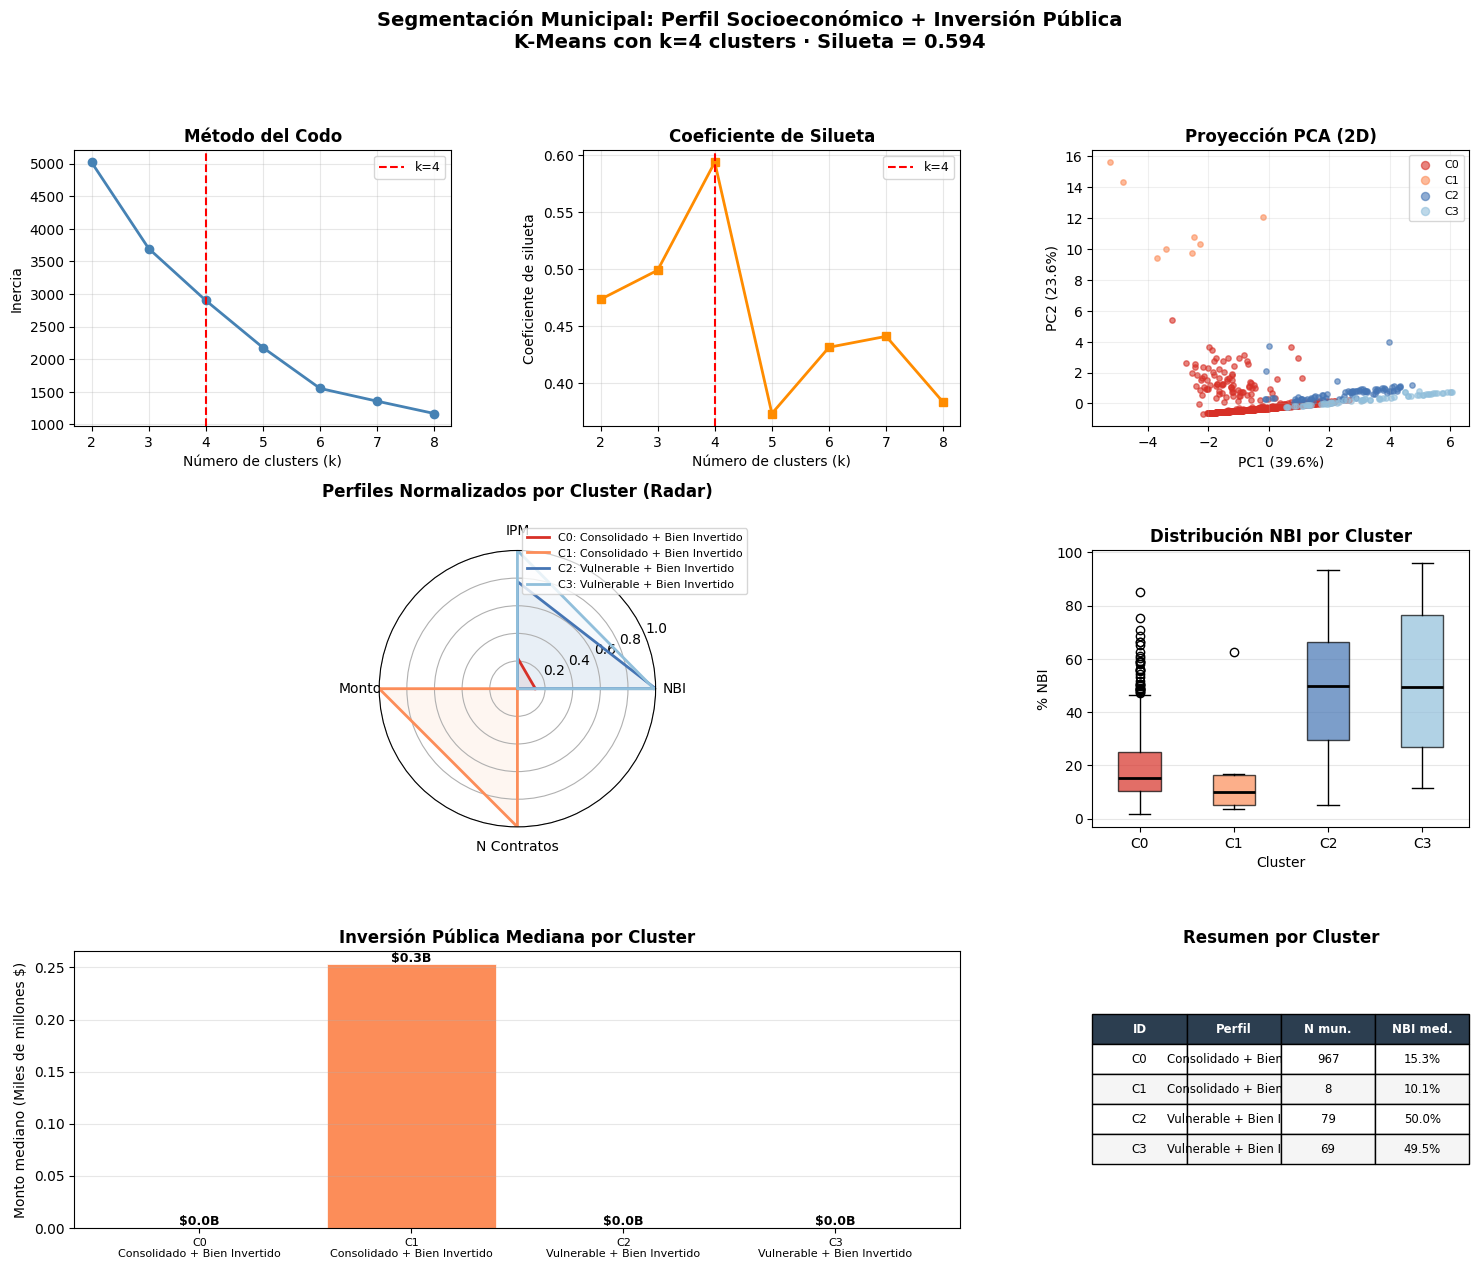


TOP 5 MUNICIPIOS POR CLUSTER

Cluster 0 — 🟢 Consolidado + Bien Invertido  (967 municipios)


,nombre_departamento,nombre_municipio,necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%),monto_total_contratos
160,BOLÍVAR,CLEMENCIA,84.943202,0.0
431,CÓRDOBA,CANALETE,75.375902,0.0
185,BOLÍVAR,SANTA ROSA,70.911565,0.0
669,MAGDALENA,NUEVA GRANADA,68.545382,0.0
172,BOLÍVAR,NOROSÍ,66.328600,0.0



Cluster 1 — 🟢 Consolidado + Bien Invertido  (8 municipios)


,nombre_departamento,nombre_municipio,necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%),monto_total_contratos
13,ANTIOQUIA,ARBOLETES,62.487157,28100000.0
1022,VALLE DEL CAUCA,EL DOVIO,16.701977,355883500.0
11,ANTIOQUIA,ANZA,16.332603,130000000.0
67,ANTIOQUIA,MACEO,13.178826,711500000.0
16,ANTIOQUIA,BARBOSA,7.012393,150000000.0



Cluster 2 — 🟠 Vulnerable + Bien Invertido  (79 municipios)


,nombre_departamento,nombre_municipio,necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%),monto_total_contratos
179,BOLÍVAR,SAN JACINTO,93.444015,0.0
588,CHOCÓ,ISTMINA,83.959194,0.0
751,NARIÑO,MAGÜI,82.508902,0.0
746,NARIÑO,LA TOLA,82.298615,0.0
70,ANTIOQUIA,MURINDÓ,81.732012,0.0



Cluster 3 — 🟠 Vulnerable + Bien Invertido  (69 municipios)


,nombre_departamento,nombre_municipio,necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%),monto_total_contratos
1103,GUAINÍA,PUERTO COLOMBIA (ANM),95.963756,0.0
1114,VAUPÉS,PACOA (ANM),93.647469,0.0
1104,GUAINÍA,LA GUADALUPE (ANM),93.630573,0.0
1106,GUAINÍA,PANA PANA (ANM),93.601651,0.0
1107,GUAINÍA,MORICHAL (ANM),92.366412,0.0



IMPLICACIONES DE POLÍTICA POR CLUSTER
  Cluster 0 (967 mun.) 🟢 Consolidado + Bien Invertido
  → Sostener trayectoria; posible modelo de buenas prácticas.
  Cluster 1 (8 mun.) 🟢 Consolidado + Bien Invertido
  → Sostener trayectoria; posible modelo de buenas prácticas.
  Cluster 2 (79 mun.) 🟠 Vulnerable + Bien Invertido
  → Mantener inversión; evaluar eficiencia y resultados de impacto.
  Cluster 3 (69 mun.) 🟠 Vulnerable + Bien Invertido
  → Mantener inversión; evaluar eficiencia y resultados de impacto.


In [4]:
# ============================================================================
# 17. CLUSTERING SOCIOECONÓMICO + INVERSIÓN PÚBLICA (K-MEANS)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── 0. Asegurar variable col_nbi ─────────────────────────────────────────
col_nbi = "necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%)"

print("=" * 65)
print("CLUSTERING MUNICIPAL: PERFIL SOCIOECONÓMICO + INVERSIÓN")
print("=" * 65)

# ── 1. Selección de variables ─────────────────────────────────────────────
candidatas = [
    col_nbi,
    'ipm_total',
    'monto_total_contratos',
    'num_contratos',
    'etnia_indigena_pct',
    'etnia_afro_pct',
    'eficiencia_inversion',
    'ticket_promedio',
]

vars_cluster = [c for c in candidatas if c in df.columns]
print(f"\n📋 Variables usadas en clustering ({len(vars_cluster)}):")
for v in vars_cluster:
    print(f"  • {v}")

# ── 2. Preparación del dataset ────────────────────────────────────────────
df_cl = df[vars_cluster + ['nombre_municipio', 'nombre_departamento']].copy()

# Convertir todas las variables a numérico (por si vienen como string)
for col in vars_cluster:
    df_cl[col] = pd.to_numeric(df_cl[col], errors='coerce')

# Transformación log para variables con distribución muy sesgada
for col in ['monto_total_contratos', 'num_contratos', 'eficiencia_inversion', 'ticket_promedio']:
    if col in df_cl.columns:
        df_cl[col] = np.log1p(df_cl[col].clip(lower=0))

# Eliminar filas con demasiados nulos (>50% de variables)
df_cl = df_cl.dropna(thresh=int(len(vars_cluster) * 0.5))

# Imputar nulos restantes con la mediana
for col in vars_cluster:
    if col in df_cl.columns:
        df_cl[col] = df_cl[col].fillna(df_cl[col].median())

print(f"\n   Municipios válidos para clustering: {len(df_cl)}")

# ── 3. Estandarización ────────────────────────────────────────────────────
X = df_cl[vars_cluster].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 4. Selección del número óptimo de clusters ────────────────────────────
inercias = []
siluetas = []
k_range  = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_scaled, labels))

k_optimo = k_range[np.argmax(siluetas)]
print(f"\n🎯 K óptimo por coeficiente de silueta: {k_optimo}")
print(f"   Silueta máxima: {max(siluetas):.4f}")

# ── 5. Modelo final ───────────────────────────────────────────────────────
km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_cl['cluster'] = km_final.fit_predict(X_scaled)

# ── 6. Perfiles de cada cluster ───────────────────────────────────────────
df_profile = df[vars_cluster + ['nombre_municipio', 'nombre_departamento']].copy()

# Convertir a numérico también en df_profile
for col in vars_cluster:
    df_profile[col] = pd.to_numeric(df_profile[col], errors='coerce')

df_profile = df_profile.loc[df_cl.index]
df_profile['cluster'] = df_cl['cluster'].values

medias     = df_profile.groupby('cluster')[vars_cluster].median()
medias_pct = (medias - medias.min()) / (medias.max() - medias.min())
conteo     = df_profile.groupby('cluster').size().rename('n_municipios')

print("\n📊 Perfil mediano de cada cluster:")
cols_show_profile = [c for c in [col_nbi, 'ipm_total', 'monto_total_contratos', 'num_contratos'] if c in vars_cluster]
display(pd.concat([conteo, medias[cols_show_profile]], axis=1).round(2))

# ── 7. Etiquetas automáticas de perfil ───────────────────────────────────
nbi_col_cl = col_nbi if col_nbi in vars_cluster else vars_cluster[0]
inv_col_cl = 'monto_total_contratos' if 'monto_total_contratos' in vars_cluster else vars_cluster[2]

nbi_med_global = medias[nbi_col_cl].median()
inv_med_global = medias[inv_col_cl].median()

def etiquetar(row):
    alto_nbi = row[nbi_col_cl] >= nbi_med_global
    alta_inv = row[inv_col_cl] >= inv_med_global
    if alto_nbi and alta_inv:      return '🟠 Vulnerable + Bien Invertido'
    if alto_nbi and not alta_inv:  return '🔴 Vulnerable + Sub-invertido'
    if not alto_nbi and alta_inv:  return '🟢 Consolidado + Bien Invertido'
    return '🟡 Consolidado + Baja Inversión'

etiquetas = medias.apply(etiquetar, axis=1)
df_cl['cluster_label']      = df_cl['cluster'].map(etiquetas)
df_profile['cluster_label'] = df_profile['cluster'].map(etiquetas)

print("\n🏷️  Perfiles identificados:")
for c, label in etiquetas.items():
    n = (df_profile['cluster'] == c).sum()
    print(f"  Cluster {c}: {label}  ({n} municipios)")

# ── 8. Visualización ──────────────────────────────────────────────────────
palette = ['#d73027','#fc8d59','#4575b4','#91bfdb','#1a9641','#a6d96a','#fdae61','#fee08b']
cluster_colors = {c: palette[i % len(palette)] for i, c in enumerate(sorted(df_profile['cluster'].unique()))}

pca = PCA(n_components=2, random_state=42)
X_pca   = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

fig = plt.figure(figsize=(18, 14))
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Segmentación Municipal: Perfil Socioeconómico + Inversión Pública\n'
             f'K-Means con k={k_optimo} clusters · Silueta = {max(siluetas):.3f}',
             fontsize=14, fontweight='bold', y=0.98)

# Panel A: Método del codo
ax_codo = fig.add_subplot(gs[0, 0])
ax_codo.plot(list(k_range), inercias, 'o-', color='steelblue', lw=2)
ax_codo.axvline(k_optimo, color='red', ls='--', label=f'k={k_optimo}')
ax_codo.set_xlabel('Número de clusters (k)')
ax_codo.set_ylabel('Inercia')
ax_codo.set_title('Método del Codo', fontweight='bold')
ax_codo.legend(fontsize=9)
ax_codo.grid(alpha=0.3)

# Panel B: Silueta
ax_sil = fig.add_subplot(gs[0, 1])
ax_sil.plot(list(k_range), siluetas, 's-', color='darkorange', lw=2)
ax_sil.axvline(k_optimo, color='red', ls='--', label=f'k={k_optimo}')
ax_sil.set_xlabel('Número de clusters (k)')
ax_sil.set_ylabel('Coeficiente de silueta')
ax_sil.set_title('Coeficiente de Silueta', fontweight='bold')
ax_sil.legend(fontsize=9)
ax_sil.grid(alpha=0.3)

# Panel C: PCA 2D
ax_pca = fig.add_subplot(gs[0, 2])
for c in sorted(df_profile['cluster'].unique()):
    idx = (df_cl['cluster'] == c).values
    ax_pca.scatter(X_pca[idx, 0], X_pca[idx, 1],
                   c=cluster_colors[c], s=15, alpha=0.6, label=f'C{c}')
ax_pca.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax_pca.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax_pca.set_title('Proyección PCA (2D)', fontweight='bold')
ax_pca.legend(fontsize=8, markerscale=1.5)
ax_pca.grid(alpha=0.2)

# Panel D: Radar de perfiles
ax_radar = fig.add_subplot(gs[1, :2], projection='polar')
vars_radar = [c for c in cols_show_profile if c in medias_pct.columns][:5]
N      = len(vars_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

labels_radar = [
    v.replace('necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%)', 'NBI')
     .replace('monto_total_contratos', 'Monto')
     .replace('num_contratos', 'N Contratos')
     .replace('ipm_total', 'IPM')
    for v in vars_radar
]

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(labels_radar, fontsize=10)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Perfiles Normalizados por Cluster (Radar)', fontweight='bold', pad=20)

for c in sorted(medias_pct.index):
    vals  = medias_pct.loc[c, vars_radar].tolist()
    vals += vals[:1]
    ax_radar.plot(angles, vals, lw=2, color=cluster_colors[c], label=f'C{c}: {etiquetas[c][2:]}')
    ax_radar.fill(angles, vals, alpha=0.08, color=cluster_colors[c])
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

# Panel E: Boxplot NBI
ax_box = fig.add_subplot(gs[1, 2])
clusters_sorted = sorted(df_profile['cluster'].unique())
data_box = [df_profile[df_profile['cluster']==c][nbi_col_cl].dropna().values for c in clusters_sorted]
bp = ax_box.boxplot(data_box, patch_artist=True, notch=False,
                    medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], clusters_sorted):
    patch.set_facecolor(cluster_colors[c])
    patch.set_alpha(0.7)
ax_box.set_xticklabels([f'C{c}' for c in clusters_sorted])
ax_box.set_xlabel('Cluster')
ax_box.set_ylabel('% NBI')
ax_box.set_title('Distribución NBI por Cluster', fontweight='bold')
ax_box.grid(axis='y', alpha=0.3)

# Panel F: Barras de inversión
ax_bar = fig.add_subplot(gs[2, :2])
inv_med_por_cluster = df_profile.groupby('cluster')[inv_col_cl].median() / 1e9
colores_bar = [cluster_colors[c] for c in inv_med_por_cluster.index]
bars = ax_bar.bar(range(len(inv_med_por_cluster)), inv_med_por_cluster.values,
                  color=colores_bar, edgecolor='white', lw=0.5)
ax_bar.set_xticks(range(len(inv_med_por_cluster)))
ax_bar.set_xticklabels([f'C{c}\n{etiquetas[c][2:30]}' for c in inv_med_por_cluster.index], fontsize=8)
ax_bar.set_ylabel('Monto mediano (Miles de millones $)')
ax_bar.set_title('Inversión Pública Mediana por Cluster', fontweight='bold')
for bar, val in zip(bars, inv_med_por_cluster.values):
    ax_bar.text(bar.get_x() + bar.get_width()/2, val,
                f'${val:.1f}B', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_bar.grid(axis='y', alpha=0.3)

# Panel G: Tabla resumen
ax_tab = fig.add_subplot(gs[2, 2])
ax_tab.axis('off')
tabla_resumen = []
for c in clusters_sorted:
    sub = df_profile[df_profile['cluster'] == c]
    tabla_resumen.append([
        f'C{c}',
        etiquetas[c][2:22] + '...' if len(etiquetas[c]) > 24 else etiquetas[c][2:],
        str(len(sub)),
        f"{sub[nbi_col_cl].median():.1f}%"
    ])
tabla_df = pd.DataFrame(tabla_resumen, columns=['ID', 'Perfil', 'N mun.', 'NBI med.'])
tbl = ax_tab.table(cellText=tabla_df.values, colLabels=tabla_df.columns,
                   loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.8)
for (r, co), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f5f5f5')
ax_tab.set_title('Resumen por Cluster', fontweight='bold', pad=6)

plt.show()

# ── 9. Top 5 municipios por cluster ──────────────────────────────────────
print("\n" + "=" * 65)
print("TOP 5 MUNICIPIOS POR CLUSTER")
print("=" * 65)

cols_disp = [c for c in ['nombre_departamento', 'nombre_municipio', col_nbi, 'monto_total_contratos'] if c in df_profile.columns]
for c in clusters_sorted:
    sub = df_profile[df_profile['cluster'] == c]
    print(f"\nCluster {c} — {etiquetas[c]}  ({len(sub)} municipios)")
    display(sub[cols_disp].sort_values(col_nbi, ascending=False).head(5))

# ── 10. Implicaciones de política ─────────────────────────────────────────
print("\n" + "=" * 65)
print("IMPLICACIONES DE POLÍTICA POR CLUSTER")
print("=" * 65)
for c in clusters_sorted:
    n     = (df_profile['cluster'] == c).sum()
    label = etiquetas[c]
    if 'Vulnerable + Sub' in label:
        accion = "→ PRIORIDAD ALTA: Aumentar inversión y focalización de recursos."
    elif 'Vulnerable + Bien' in label:
        accion = "→ Mantener inversión; evaluar eficiencia y resultados de impacto."
    elif 'Consolidado + Bien' in label:
        accion = "→ Sostener trayectoria; posible modelo de buenas prácticas."
    else:
        accion = "→ Revisar si la baja inversión responde a menor necesidad o a subregistro."
    print(f"  Cluster {c} ({n} mun.) {label}")
    print(f"  {accion}")

In [5]:
df[['nombre_departamento','nombre_municipio','divipola_municipio',
    'necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%)',
    'ipm_total','monto_total_contratos']].to_csv('datos_vuln.csv', index=False)